In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("nih-chest-xrays/data")

# print("Path to dataset files:", path)

# Imports

In [3]:
# tf.keras.backend.clear_session()

In [4]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()
print("TensorFlow:", tf.__version__)


2026-05-10 15:38:22.351940: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778427502.545287      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778427502.600586      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778427503.072121      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778427503.072156      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778427503.072159      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


# Load metadata and connect images

In [5]:
BASE_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = os.path.join(BASE_PATH, "Data_Entry_2017.csv")

image_paths = {}
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith(".png"):
            image_paths[file] = os.path.join(root, file)

print("Total images found:", len(image_paths))

df = pd.read_csv(CSV_PATH)
print("Metadata shape:", df.shape)
df.head()


Total images found: 112120
Metadata shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [6]:
df = df.copy()

if "View Position" in df.columns:
    df = df[df["View Position"].isin(["PA", "AP"])].copy()

df = df[
    (df["Finding Labels"] == "No Finding") |
    (df["Finding Labels"].str.contains("Pneumonia", na=False))
].copy()

df["label"] = df["Finding Labels"].apply(lambda x: 1 if "Pneumonia" in x else 0)
df["path"] = df["Image Index"].map(image_paths)

keep_cols = ["Image Index", "Finding Labels", "label", "path"]
if "Patient ID" in df.columns:
    keep_cols.append("Patient ID")
if "View Position" in df.columns:
    keep_cols.append("View Position")

df = df[keep_cols].dropna(subset=["path"]).drop_duplicates().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()


Filtered dataset shape: (61792, 6)
label
0    60361
1     1431
Name: count, dtype: int64


,Image Index,Finding Labels,label,path,Patient ID,View Position
0,00000002_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,2,PA
1,00000005_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA
2,00000005_001.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
3,00000005_002.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
4,00000005_003.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA


In [7]:
df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                  60361
Pneumonia                                                     322
Infiltration|Pneumonia                                        199
Edema|Infiltration|Pneumonia                                  137
Atelectasis|Pneumonia                                         108
                                                            ...  
Mass|Nodule|Pneumonia|Pneumothorax                              1
Atelectasis|Effusion|Infiltration|Pneumonia|Pneumothorax        1
Cardiomegaly|Consolidation|Effusion|Pneumonia                   1
Consolidation|Nodule|Pneumonia                                  1
Consolidation|Pneumonia|Mass                                    1
Name: count, Length: 143, dtype: int64

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nUnique patients:", df["Patient ID"].nunique() if "Patient ID" in df.columns else "Patient ID not found")
print("Unique images:", df["Image Index"].nunique())
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))


Missing values per column:
Image Index       0
Finding Labels    0
label             0
path              0
Patient ID        0
View Position     0
dtype: int64

Unique patients: 25052
Unique images: 61792

Class distribution:
label
0    0.976842
1    0.023158
Name: ratio, dtype: float64


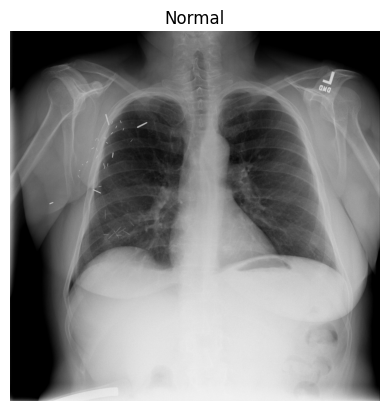

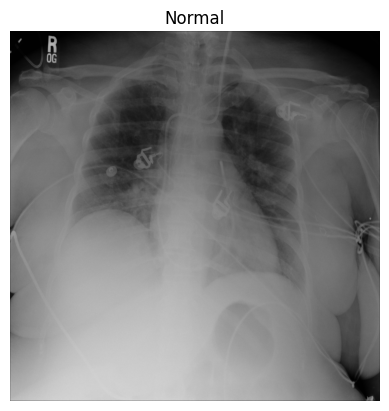

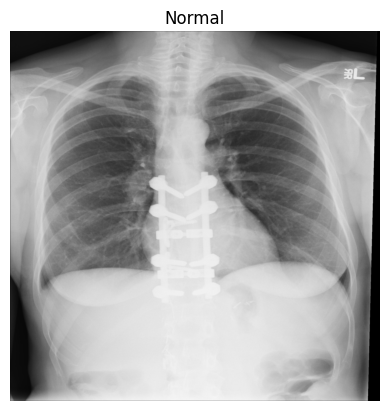

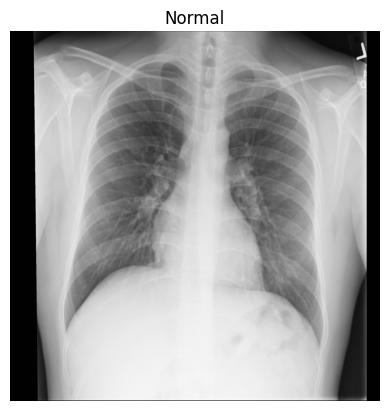

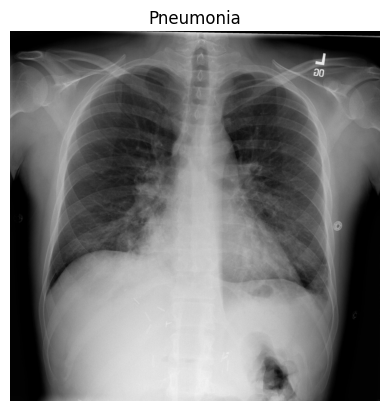

In [9]:
import cv2
import matplotlib.pyplot as plt

sample = df.sample(5)

for _, row in sample.iterrows():
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")
    plt.show()

# Data preprocessing

In [10]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())

if "Patient ID" in df.columns:
    patient_level = df.groupby("Patient ID")["label"].max().value_counts()
    print("\nPatient-level label distribution:")
    print(patient_level)

print("\nImage-level label distribution:")
print(df["label"].value_counts())


Duplicates before: 0
Duplicates after: 0

Patient-level label distribution:
label
0    24044
1     1008
Name: count, dtype: int64

Image-level label distribution:
label
0    60361
1     1431
Name: count, dtype: int64


# Class imbalance strategy

label
0    60361
1     1431
Name: count, dtype: int64
(61792, 6)


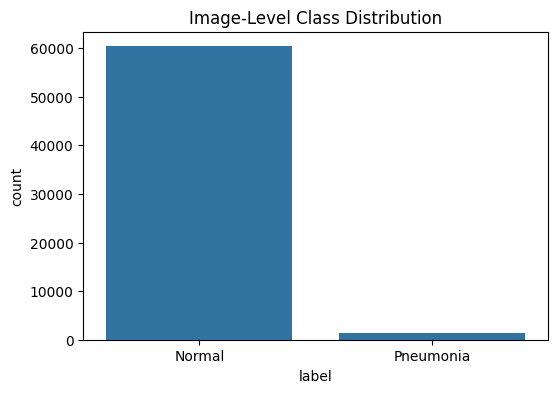

In [11]:
df_model = df.copy().reset_index(drop=True)

print(df_model["label"].value_counts())
print(df_model.shape)

plt.figure(figsize=(6, 4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Image-Level Class Distribution")
plt.show()


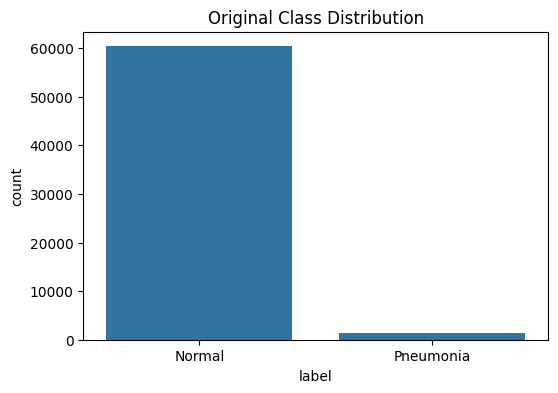

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Original Class Distribution")
plt.show()


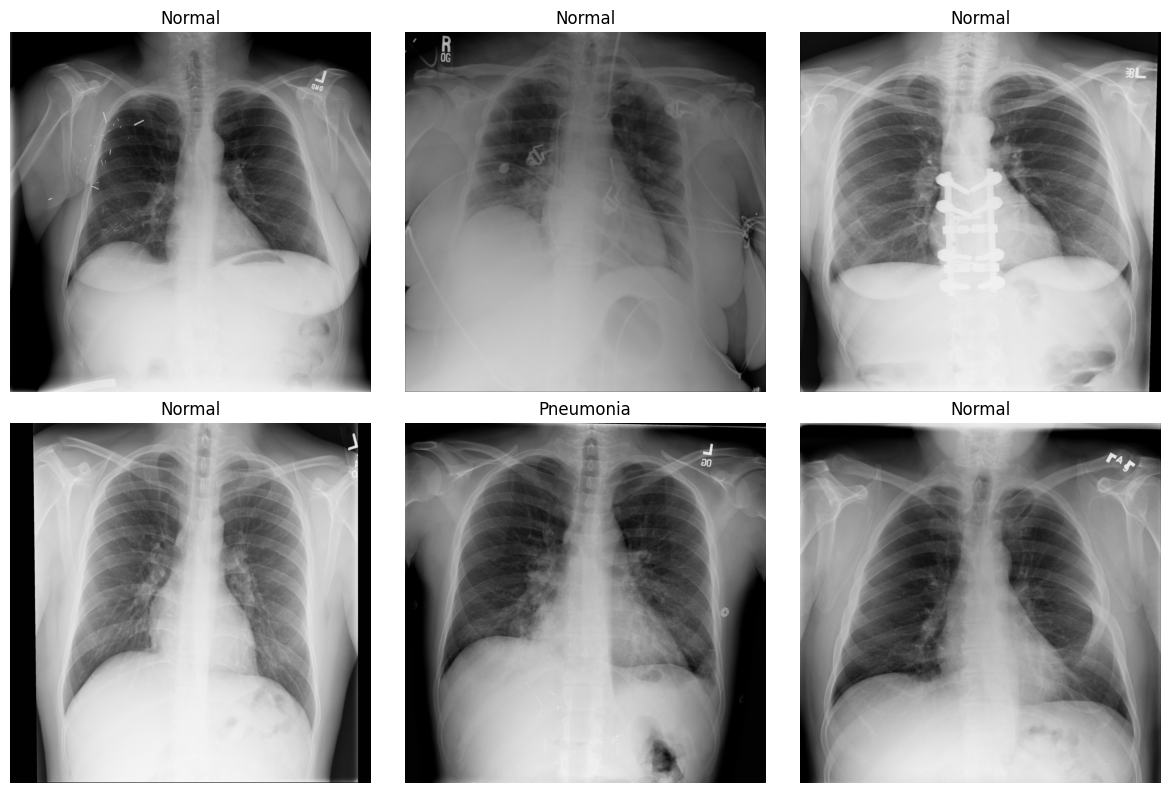

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
samples = df_model.sample(6, random_state=42).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img = cv2.imread(samples.loc[i, "path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Pneumonia" if samples.loc[i, "label"] == 1 else "Normal")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [14]:
sizes = []

for p in df_model["path"].sample(min(200, len(df_model)), random_state=42):
    img = cv2.imread(p)
    if img is not None:
        sizes.append(img.shape[:2])

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])
sizes_df.describe()


,Height,Width
count,200.0,200.0
mean,1024.0,1024.0
std,0.0,0.0
min,1024.0,1024.0
25%,1024.0,1024.0
50%,1024.0,1024.0
75%,1024.0,1024.0
max,1024.0,1024.0


In [15]:
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)

class_weights = {0: 1.0, 1: 2.0}

In [16]:
assert "Patient ID" in df_model.columns, "Patient ID column is required for patient-level split."

patient_labels = df_model.groupby("Patient ID")["label"].max().reset_index()

train_pat, temp_pat = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["label"],
    random_state=SEED
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.50,
    stratify=temp_pat["label"],
    random_state=SEED
)

train_df = df_model[df_model["Patient ID"].isin(train_pat["Patient ID"])].copy()
val_df   = df_model[df_model["Patient ID"].isin(val_pat["Patient ID"])].copy()
test_df  = df_model[df_model["Patient ID"].isin(test_pat["Patient ID"])].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())
print("\nTest label counts:")
print(test_df["label"].value_counts())

assert set(train_df["Patient ID"]).isdisjoint(set(val_df["Patient ID"]))
assert set(train_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
assert set(val_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
print("\nNo patient leakage detected.")


Train: (43018, 6)
Validation: (9271, 6)
Test: (9503, 6)

Train label counts:
label
0    42043
1      975
Name: count, dtype: int64

Validation label counts:
label
0    9070
1     201
Name: count, dtype: int64

Test label counts:
label
0    9248
1     255
Name: count, dtype: int64

No patient leakage detected.


In [17]:
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print(class_weights)


{0: 0.5115952715077421, 1: 22.06051282051282}


Original TRAIN distribution:
Counter({0: 42043, 1: 975})


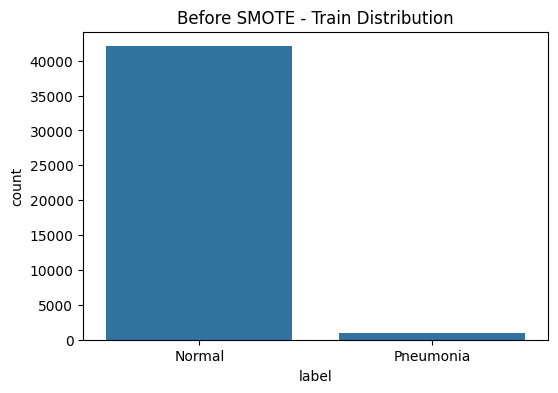


After SMOTE:
Counter({0: 42043, 1: 21021})


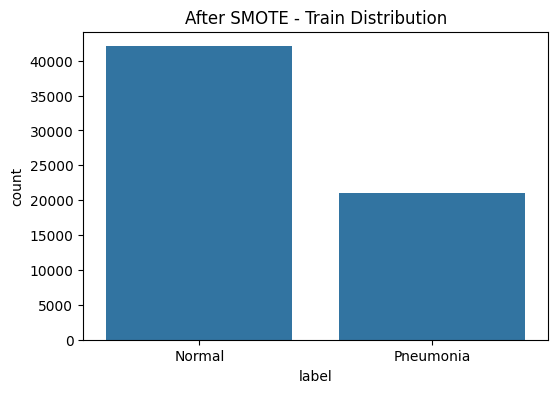


Final image-train distribution:
label
0    42043
1    21021
Name: count, dtype: int64


In [18]:
# =========================
# CLASS IMBALANCE REVIEW
# =========================
from collections import Counter
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

print("Original TRAIN distribution:")
print(Counter(train_df["label"]))

plt.figure(figsize=(6,4))
sns.countplot(x=train_df["label"])
plt.xticks([0,1], ["Normal", "Pneumonia"])
plt.title("Before SMOTE - Train Distribution")
plt.show()


# ==========================================================
# FEATURE PREP FOR SMOTE
# ==========================================================
# Since SMOTE cannot use image paths directly,
# we use structured metadata for balancing support
# (Age + Gender + View Position)
# ==========================================================

smote_train = train_df.copy()

# Gender
if "Patient Gender" in df.columns:
    gender_map = df[["Image Index", "Patient Gender"]].drop_duplicates()
    gender_map["Patient Gender"] = gender_map["Patient Gender"].map({"M":0, "F":1})
    smote_train = smote_train.merge(
        gender_map,
        on="Image Index",
        how="left"
    )
else:
    smote_train["Patient Gender"] = 0

# Age
if "Patient Age" in df.columns:
    age_map = df[["Image Index", "Patient Age"]].drop_duplicates()
    smote_train = smote_train.merge(
        age_map,
        on="Image Index",
        how="left"
    )
else:
    smote_train["Patient Age"] = 50

# View
smote_train["View Position"] = smote_train["View Position"].map({"PA":0, "AP":1})

# Fill
smote_train["Patient Age"] = smote_train["Patient Age"].fillna(smote_train["Patient Age"].median())
smote_train["Patient Gender"] = smote_train["Patient Gender"].fillna(0)

X_train_smote = smote_train[["Patient Age", "Patient Gender", "View Position"]]
y_train_smote = smote_train["label"]


# =========================
# APPLY SMOTE
# =========================
smote = SMOTE(
    sampling_strategy=0.5,   # minority becomes 50% of majority
    random_state=SEED,
    k_neighbors=3
)

X_resampled, y_resampled = smote.fit_resample(X_train_smote, y_train_smote)

print("\nAfter SMOTE:")
print(Counter(y_resampled))


# =========================
# VISUALIZE
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.xticks([0,1], ["Normal", "Pneumonia"])
plt.title("After SMOTE - Train Distribution")
plt.show()


# =========================
# BUILD BALANCED TRAIN DF
# =========================
normal_df = train_df[train_df["label"] == 0].copy()
pneumonia_df = train_df[train_df["label"] == 1].copy()

target_pneumonia = Counter(y_resampled)[1]

pneumonia_upsampled = pneumonia_df.sample(
    n=target_pneumonia,
    replace=True,
    random_state=SEED
)

train_df_balanced = pd.concat(
    [normal_df, pneumonia_upsampled],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nFinal image-train distribution:")
print(train_df_balanced["label"].value_counts())

In [19]:
IMG_SIZE = 299   
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
    tf.keras.layers.RandomZoom(0.05, 0.05),
], name="train_augmentation")


def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label


def prepare_train(path, label):
    image, label = decode_image(path, label)
    image = train_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label


def prepare_eval(path, label):
    image, label = decode_image(path, label)
    image = preprocess_input(image)
    return image, label


def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["path"].values,
        dataframe["label"].values.astype("float32")
    ))

    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(prepare_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(prepare_eval, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

I0000 00:00:1778427673.752013      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778427673.758423      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [20]:
train_gen = make_dataset(train_df, training=True)
val_gen = make_dataset(val_df, training=False)
test_gen = make_dataset(test_df, training=False)

for images, labels in train_gen.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Batch label distribution:", np.unique(labels.numpy(), return_counts=True))


Batch image shape: (16, 299, 299, 3)
Batch label shape: (16,)
Batch label distribution: (array([0., 1.], dtype=float32), array([15,  1]))


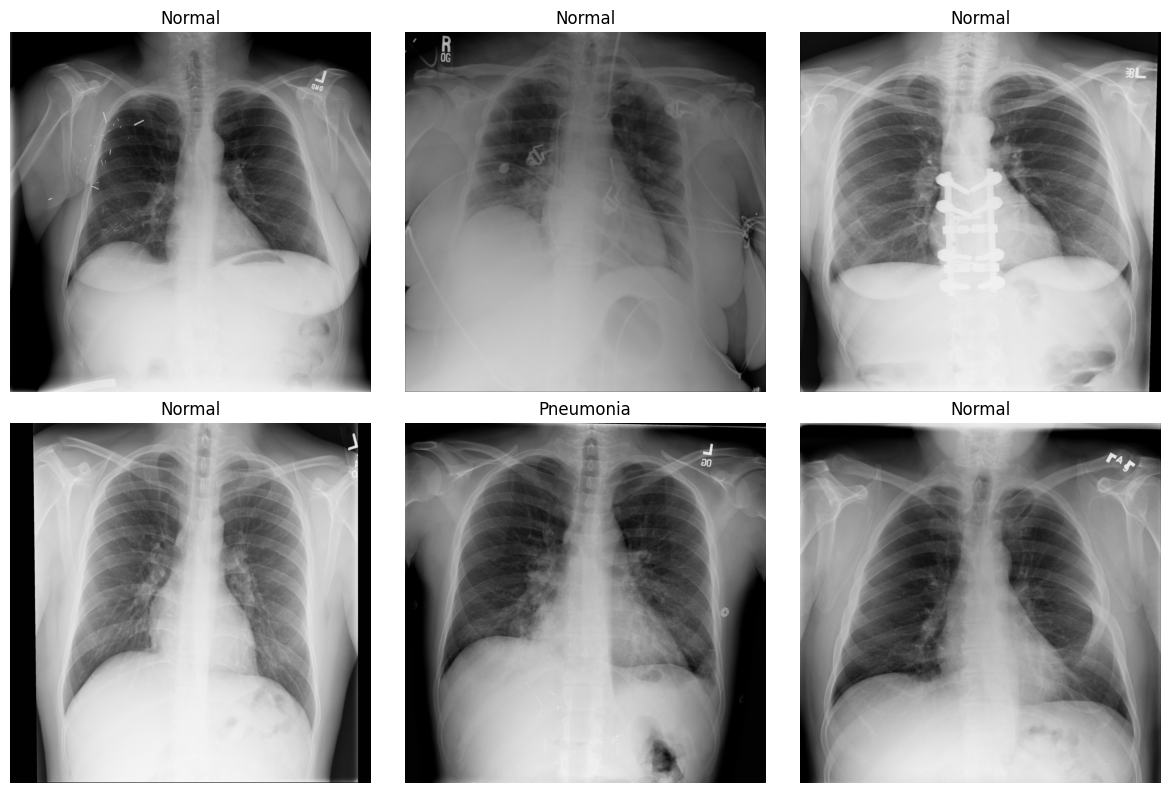

In [21]:
import matplotlib.pyplot as plt
import cv2

samples = df_model.sample(6, random_state=42)

plt.figure(figsize=(12, 8))
for i, (_, row) in enumerate(samples.iterrows()):
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Resnet 152v2

In [23]:
from tensorflow.keras.layers import BatchNormalization
base_model = tf.keras.applications.ResNet152V2(
    include_top=False,                        # remove the ImageNet classifier
    weights='imagenet',                       # pre-trained on ImageNet
    input_tensor=None,                        # we pass shape directly
    input_shape=(IMG_SIZE, IMG_SIZE, 3),      # 224 × 224 × 3
    pooling=None,                             # pooling handled by custom head
    # classes & classifier_activation only apply when include_top=True
)

# Freeze backbone for head-training phase
base_model.trainable = False

# ── Custom classification head ───────────────────────────────────────────────
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)   # frozen backbone
x       = GlobalAveragePooling2D()(x)
x       = BatchNormalization()(x)
x       = Dropout(0.4)(x)
outputs = Dense(
    1,
    activation='sigmoid',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

resnet_model = Model(inputs, outputs, name='ResNet152V2_Pneumonia')

# ── Loss & metrics (identical to Xception notebook) ─────────────────────────
metrics = [
    tf.keras.metrics.AUC(name='auc',    curve='ROC'),
    tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

loss_fn = tf.keras.losses.BinaryFocalCrossentropy(
    gamma=2.0,
    apply_class_balancing=True
)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=metrics
)

resnet_model.summary()

Model: "ResNet152V2_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 10, 10, 2048)   │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,341,889 (222.56 MB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 58,335,744 (222.53 MB)

In [24]:
callbacks_head = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=4, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max',
        factor=0.3, patience=2, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        '/kaggle/working/best_resnet152v2_head.keras',
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=1
    )
]

history_head = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_head,
    verbose=1
)

resnet_model.save('/kaggle/working/resnet152v2_head_final.keras')
print('✅ ResNet152V2 head-trained model saved.')

Epoch 1/10


I0000 00:00:1778427886.846654     137 service.cc:152] XLA service 0x7efc4c0afbb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778427886.846707     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778427886.846712     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778427892.185204     137 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778427900.785830     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - auc: 0.5335 - loss: 0.1553 - pr_auc: 0.0271 - precision: 0.0262 - recall: 0.3406
Epoch 1: val_auc improved from -inf to 0.69359, saving model to /kaggle/working/best_resnet152v2_head.keras
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 1182s 428ms/step - auc: 0.5335 - loss: 0.1553 - pr_auc: 0.0271 - precision: 0.0262 - recall: 0.3406 - val_auc: 0.6936 - val_loss: 0.0553 - val_pr_auc: 0.0442 - val_precision: 0.0624 - val_recall: 0.2687 - learning_rate: 1.0000e-04
Epoch 2/10
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - auc: 0.6064 - loss: 0.1208 - pr_auc: 0.0352 - precision: 0.0365 - recall: 0.3181
Epoch 2: val_auc did not improve from 0.69359
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 1082s 402ms/step - auc: 0.6064 - loss: 0.1208 - pr_auc: 0.0352 - precision: 0.0364 - recall: 0.3181 - val_auc: 0.6052 - val_loss: 0.0476 - val_pr_auc: 0.0316 - val_precision: 0.0405 - val_recall: 0.0995 - learning_rate: 1.0000e-04
Epoch 3/10
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step

KeyboardInterrupt: 

In [29]:
history_ft = tf.keras.models.load_model('/kaggle/working/best_resnet152v2_finetuned.keras')
# history_head = tf.keras.models.load_model('/kaggle/working/best_resnet152v2_keras.keras')


ValueError: File not found: filepath=/kaggle/working/best_resnet152v2_keras.keras. Please ensure the file is an accessible `.keras` zip file.

In [25]:
base_model.trainable = True

# Freeze all layers except the last 50
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Confirm how many layers are trainable
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable layers in backbone: {trainable_count} / {len(base_model.layers)}')

# Recompile with a lower learning rate for fine-tuning
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=metrics
)

callbacks_ft = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=4, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max',
        factor=0.3, patience=2, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        '/kaggle/working/best_resnet152v2_finetuned.keras',
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=1
    )
]

history_ft = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks_ft,
    verbose=1
)

resnet_model.save('/kaggle/working/resnet152v2_finetuned_final.keras')
resnet_model.save('/kaggle/working/resnet152v2_finetuned_final.h5')
print('✅ ResNet152V2 fine-tuned model saved.')

Trainable layers in backbone: 50 / 564
Epoch 1/5
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - auc: 0.5820 - loss: 0.1302 - pr_auc: 0.0299 - precision: 0.0314 - recall: 0.3425
Epoch 1: val_auc improved from -inf to 0.64185, saving model to /kaggle/working/best_resnet152v2_finetuned.keras
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 1286s 465ms/step - auc: 0.5820 - loss: 0.1302 - pr_auc: 0.0299 - precision: 0.0314 - recall: 0.3425 - val_auc: 0.6419 - val_loss: 0.0659 - val_pr_auc: 0.0362 - val_precision: 0.0418 - val_recall: 0.2736 - learning_rate: 1.0000e-05
Epoch 2/5
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - auc: 0.6144 - loss: 0.0905 - pr_auc: 0.0347 - precision: 0.0393 - recall: 0.2540
Epoch 2: val_auc did not improve from 0.64185
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 1225s 455ms/step - auc: 0.6144 - loss: 0.0905 - pr_auc: 0.0347 - precision: 0.0393 - recall: 0.2540 - val_auc: 0.6415 - val_loss: 0.0537 - val_pr_auc: 0.0425 - val_precision: 0.0778 - val_recall: 0.2040 - learning_rate: 1.0000e-05
Ep

KeyboardInterrupt: 

In [26]:
def plot_history(histories, metric='auc'):
    plt.figure(figsize=(8, 5))
    for name, hist in histories.items():
        hd = hist.history
        if metric in hd and f'val_{metric}' in hd:
            plt.plot(hd[metric],         label=f'{name} train')
            plt.plot(hd[f'val_{metric}'], label=f'{name} val')
    plt.title(metric.upper())
    plt.xlabel('Epoch')
    plt.ylabel(metric.upper())
    plt.legend()
    plt.show()


histories = {
    'resnet152v2_head':      history_head,
    'resnet152v2_fine_tune': history_ft
}

for metric_name in ['loss', 'auc', 'pr_auc', 'precision', 'recall']:
    plot_history(histories, metric_name)

NameError: name 'history_head' is not defined

In [30]:
# Load best saved model
resnet_model = tf.keras.models.load_model('/kaggle/working/best_resnet152v2_finetuned.keras')

val_true = val_df['label'].values.astype(int)
val_prob = resnet_model.predict(val_gen, verbose=1).ravel()

precisions, recalls, thresholds = precision_recall_curve(val_true, val_prob)
f1_scores = (
    2 * precisions[:-1] * recalls[:-1]
    / (precisions[:-1] + recalls[:-1] + 1e-8)
)

best_idx               = np.argmax(f1_scores)
best_threshold_resnet  = thresholds[best_idx]

print('Best ResNet152V2 threshold:', best_threshold_resnet)
print('Best validation F1:',         f1_scores[best_idx])

580/580 ━━━━━━━━━━━━━━━━━━━━ 127s 204ms/step
Best ResNet152V2 threshold: 0.4726183
Best validation F1: 0.09876543009732572


In [31]:
y_true = test_df['label'].values.astype(int)
y_prob = resnet_model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= best_threshold_resnet).astype(int)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print('Confusion Matrix:')
print(cm)
print('\nClassification Report:')
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print('ROC-AUC:     ', roc_auc_score(y_true, y_prob))
print('PR-AUC:      ', average_precision_score(y_true, y_prob))
print('Precision:   ', precision_score(y_true, y_pred, zero_division=0))
print('Recall:      ', recall_score(y_true, y_pred, zero_division=0))
print('F1:          ', f1_score(y_true, y_pred, zero_division=0))
print('Specificity: ', tn / (tn + fp + 1e-8))

594/594 ━━━━━━━━━━━━━━━━━━━━ 120s 201ms/step
Confusion Matrix:
[[7749 1499]
 [ 134  121]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9830    0.8379    0.9047      9248
           1     0.0747    0.4745    0.1291       255

    accuracy                         0.8282      9503
   macro avg     0.5288    0.6562    0.5169      9503
weighted avg     0.9586    0.8282    0.8839      9503

ROC-AUC:      0.7254075072935748
PR-AUC:       0.06699831219061209
Precision:    0.07469135802469136
Recall:       0.4745098039215686
F1:           0.12906666666666666
Specificity:  0.8379108996530731


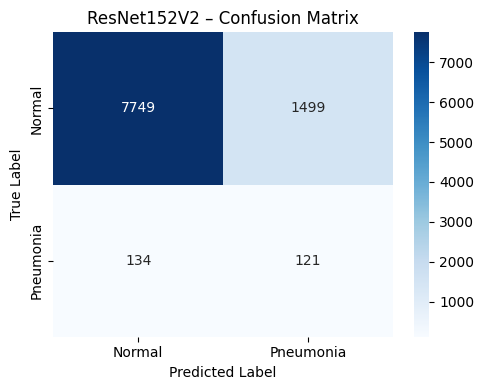

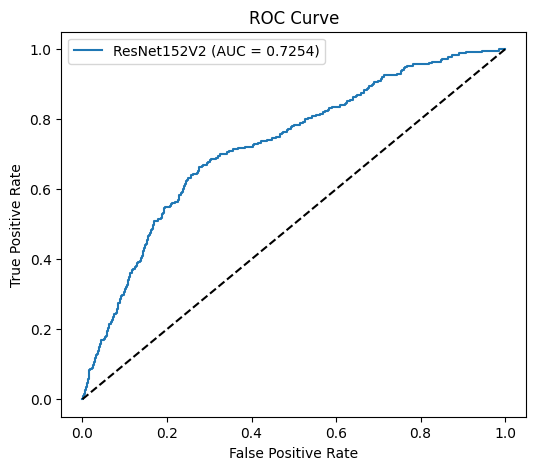

In [32]:
# ── Confusion-matrix heatmap ─────────────────────────────────────────────────
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Pneumonia'],
    yticklabels=['Normal', 'Pneumonia']
)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('ResNet152V2 – Confusion Matrix')
plt.tight_layout()
plt.show()

# ── ROC Curve ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_val     = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ResNet152V2 (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

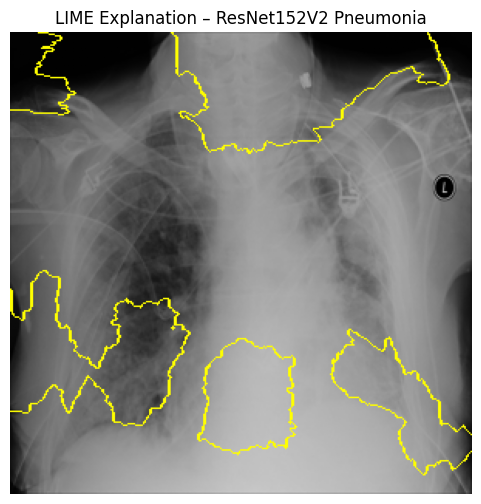

True label:            Pneumonia
Predicted probability: 0.5101
Predicted label:       Pneumonia
Threshold used:        0.4726183


In [33]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image as PILImage

explainer_lime = lime_image.LimeImageExplainer()


def predict_fn_resnet(images):
    """LIME-compatible prediction function."""
    images = np.array(images).astype('float32')
    images = preprocess_input(images)
    probs  = resnet_model.predict(images, verbose=0)
    if probs.shape[-1] == 1:
        probs = probs.ravel()
        return np.stack([1 - probs, probs], axis=1)
    return probs


# Pick a pneumonia test sample
sample_row = test_df[test_df['label'] == 1].sample(1, random_state=SEED).iloc[0]
img_path   = sample_row['path']

img     = PILImage.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
img_np  = np.array(img)

explanation = explainer_lime.explain_instance(
    img_np,
    predict_fn_resnet,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    label=1, positive_only=True, num_features=10, hide_rest=False
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title('LIME Explanation – ResNet152V2 Pneumonia')
plt.axis('off')
plt.show()

pred_prob = float(
    resnet_model.predict(
        preprocess_input(np.expand_dims(img_np.astype('float32'), axis=0)),
        verbose=0
    ).ravel()[0]
)
print('True label:            Pneumonia')
print('Predicted probability:', round(pred_prob, 4))
print('Predicted label:      ', 'Pneumonia' if pred_prob >= best_threshold_resnet else 'Normal')
print('Threshold used:       ', best_threshold_resnet)

  0%|          | 0/198 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/198 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:29<00:00,  2.86s/it]

  0%|          | 0/198 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:34, 11.56s/it]                       


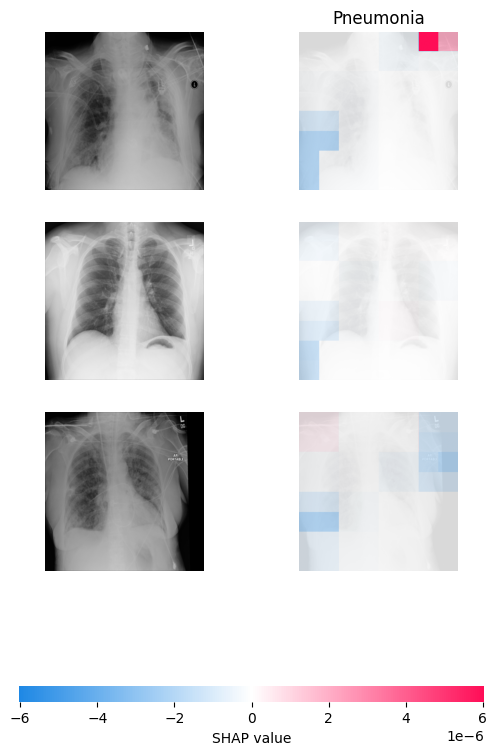

Image 1
  True label:  Pneumonia
  Prob:        0.5101
  Prediction:  Pneumonia
----------------------------------------
Image 2
  True label:  Pneumonia
  Prob:        0.284
  Prediction:  Normal
----------------------------------------
Image 3
  True label:  Pneumonia
  Prob:        0.4703
  Prediction:  Normal
----------------------------------------


In [36]:
import shap


def load_resnet_image(path, size=(IMG_SIZE, IMG_SIZE)):
    img = PILImage.open(path).convert('RGB').resize(size)
    return np.array(img).astype('float32')


background_paths = test_df[test_df['label'] == 0]['path'].sample(20, random_state=SEED).values
explain_paths    = test_df[test_df['label'] == 1]['path'].sample(3,  random_state=SEED).values

background  = np.array([load_resnet_image(p) for p in background_paths])
to_explain  = np.array([load_resnet_image(p) for p in explain_paths])

background_preprocessed = preprocess_input(background.copy())
to_explain_preprocessed = preprocess_input(to_explain.copy())


def predict_resnet_shap(images):
    images = images.astype('float32')
    images = preprocess_input(images.copy())
    return resnet_model.predict(images, verbose=0)


masker   = shap.maskers.Image('blur(32,32)', shape=(IMG_SIZE, IMG_SIZE, 3))
explainer_shap = shap.Explainer(
    predict_resnet_shap,
    masker,
    output_names=['Pneumonia']
)

shap_values = explainer_shap(to_explain, max_evals=200, batch_size=8)
shap.image_plot(shap_values, to_explain / 255.0)

# Per-image predictions
pred_probs = resnet_model.predict(to_explain_preprocessed, verbose=0).ravel()
for i, prob in enumerate(pred_probs):
    pred_label = int(prob >= best_threshold_resnet)
    print(f'Image {i+1}')
    print('  True label:  Pneumonia')
    print('  Prob:       ', round(float(prob), 4))
    print('  Prediction: ', 'Pneumonia' if pred_label == 1 else 'Normal')
    print('-' * 40)

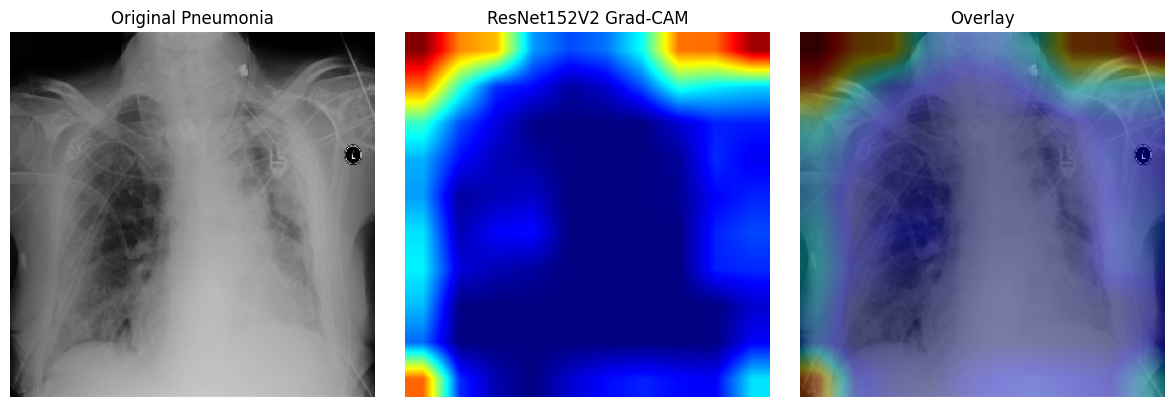

Saved to: /kaggle/working/outputs/resnet152v2_gradcam_pneumonia.png
True label:            Pneumonia
Predicted probability: 0.5111
Predicted label:       Pneumonia
Threshold used:        0.4726183


In [37]:
def load_image_for_resnet(img_path, size=(IMG_SIZE, IMG_SIZE)):
    """Load & preprocess a single image for ResNet152V2 inference."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, size)
    img = tf.image.grayscale_to_rgb(img)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return tf.expand_dims(img, axis=0)


def get_gradcam_heatmap_resnet(
    model,
    img_array,
    last_conv_layer_name='post_bn',    # ResNet152V2 final activation after last BN
    class_index=None
):
    """
    Compute Grad-CAM heatmap for a ResNet152V2-based model.

    ResNet152V2 layer naming convention
    ------------------------------------
    The backbone ends with:
        conv5_block3_2_conv   → conv5_block3_2_bn   → post_bn (pre-activation BN)
    'post_bn' is the last feature-map layer before GlobalAveragePooling.
    """
    # Locate the backbone sub-model inside the functional model
    backbone = None
    top_start_idx = None
    for i, layer in enumerate(model.layers):
        if isinstance(layer, tf.keras.Model):
            backbone = layer
            top_start_idx = i + 1
            break
    if backbone is None:
        raise ValueError('ResNet152V2 backbone not found inside the model.')

    last_conv_layer = backbone.get_layer(last_conv_layer_name)

    grad_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = grad_model(img_array, training=False)
        x = base_outputs
        for layer in model.layers[top_start_idx:]:
            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)
        preds = x
        loss  = preds[:, 0] if preds.shape[-1] == 1 else preds[:, class_index or tf.argmax(preds[0])]

    grads = tape.gradient(loss, conv_outputs)
    if grads is None:
        raise ValueError('Gradients are None – check last_conv_layer_name.')

    pooled_grads  = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs  = conv_outputs[0]
    heatmap       = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap       = tf.maximum(heatmap, 0)
    max_val       = tf.reduce_max(heatmap)
    heatmap       = heatmap / (max_val + 1e-8)
    return heatmap.numpy()


def show_resnet_gradcam(
    model,
    test_df,
    best_threshold,
    seed=42,
    save_dir='/kaggle/working/outputs',
    last_conv_layer_name='post_bn'
):
    os.makedirs(save_dir, exist_ok=True)

    sample_row = test_df[test_df['label'] == 1].sample(1, random_state=seed).iloc[0]
    img_path   = sample_row['path']

    img_array = load_image_for_resnet(img_path)
    pred      = model.predict(img_array, verbose=0)
    pred_prob = float(pred[0][0])
    pred_label = int(pred_prob >= best_threshold)

    heatmap = get_gradcam_heatmap_resnet(
        model, img_array,
        last_conv_layer_name=last_conv_layer_name
    )

    img_gray     = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_gray     = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
    img_rgb      = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

    heatmap_r    = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_u8   = np.uint8(255 * heatmap_r)
    heatmap_col  = cv2.applyColorMap(heatmap_u8, cv2.COLORMAP_JET)
    heatmap_col  = cv2.cvtColor(heatmap_col, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(img_rgb, 0.65, heatmap_col, 0.35, 0)

    save_path = os.path.join(save_dir, 'resnet152v2_gradcam_pneumonia.png')

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(img_rgb, cmap='gray');    plt.title('Original Pneumonia'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(heatmap_col);              plt.title('ResNet152V2 Grad-CAM'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(superimposed);             plt.title('Overlay'); plt.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print('Saved to:', save_path)
    print('True label:            Pneumonia')
    print('Predicted probability:', round(pred_prob, 4))
    print('Predicted label:      ', 'Pneumonia' if pred_label == 1 else 'Normal')
    print('Threshold used:       ', best_threshold)
    return heatmap, save_path


# Run Grad-CAM
heatmap, _ = show_resnet_gradcam(
    resnet_model, test_df, best_threshold_resnet
)

In [43]:
# ============================================================
# Safer metadata feature builder
# ============================================================

def build_meta_features(df_subset):
    feats = pd.DataFrame(index=df_subset.index)

    # Age
    if 'Patient Age' in df_subset.columns:
        age = pd.to_numeric(df_subset['Patient Age'], errors='coerce')
        age = age.fillna(age.median())

        # If median is still NaN because the whole column is missing
        age = age.fillna(50)

        feats['Age'] = age
    else:
        feats['Age'] = 50.0

    # Gender
    if 'Patient Gender' in df_subset.columns:
        gender = df_subset['Patient Gender'].astype(str).str.upper().str.strip()
        feats['Gender'] = gender.map({
            'M': 0,
            'MALE': 0,
            'F': 1,
            'FEMALE': 1
        }).fillna(0)
    else:
        feats['Gender'] = 0

    # View Position
    if 'View Position' in df_subset.columns:
        view = df_subset['View Position'].astype(str).str.upper().str.strip()
        feats['ViewPos'] = view.map({
            'PA': 0,
            'AP': 1
        }).fillna(0)
    else:
        feats['ViewPos'] = 0

    return feats.astype(np.float32)


test_meta = build_meta_features(test_df).values
train_meta = build_meta_features(train_sample).reset_index(drop=True).values

# ============================================================
# Remove NaNs from embeddings too
# ============================================================

train_emb = np.nan_to_num(train_emb, nan=0.0, posinf=0.0, neginf=0.0)
test_emb  = np.nan_to_num(test_emb,  nan=0.0, posinf=0.0, neginf=0.0)

train_meta = np.nan_to_num(train_meta, nan=0.0, posinf=0.0, neginf=0.0)
test_meta  = np.nan_to_num(test_meta,  nan=0.0, posinf=0.0, neginf=0.0)

# ============================================================
# Combine embeddings + metadata
# ============================================================

X_train_combined = np.concatenate([train_emb, train_meta], axis=1)
X_test_combined  = np.concatenate([test_emb,  test_meta],  axis=1)

y_train_sub = train_sample['label'].values
y_test_sub  = test_df['label'].values

# Final safety check
print("NaNs in X_train_combined:", np.isnan(X_train_combined).sum())
print("NaNs in X_test_combined:", np.isnan(X_test_combined).sum())
print("Train combined shape:", X_train_combined.shape)
print("Test combined shape:", X_test_combined.shape)

# ============================================================
# Train surrogate model
# ============================================================

surrogate = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=SEED
)

surrogate.fit(X_train_combined, y_train_sub)

print('Surrogate model accuracy:', surrogate.score(X_test_combined, y_test_sub))

NaNs in X_train_combined: 0
NaNs in X_test_combined: 0
Train combined shape: (500, 2051)
Test combined shape: (9503, 2051)
Surrogate model accuracy: 0.8203725139429654


In [47]:
X_train_combined = np.nan_to_num(X_train_combined, nan=0.0)

Embedding model output shape: (None, 2048)
Extracting test embeddings...
297/297 ━━━━━━━━━━━━━━━━━━━━ 130s 407ms/step
Test embeddings shape: (9503, 2048)
Extracting train embeddings sample...
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 591ms/step
Train embeddings shape: (500, 2048)
Combined feature shape — train: (500, 2051)
Combined feature shape — test: (9503, 2051)
NaNs in train: 0
NaNs in test: 0
Surrogate model accuracy: 0.8436283278964537


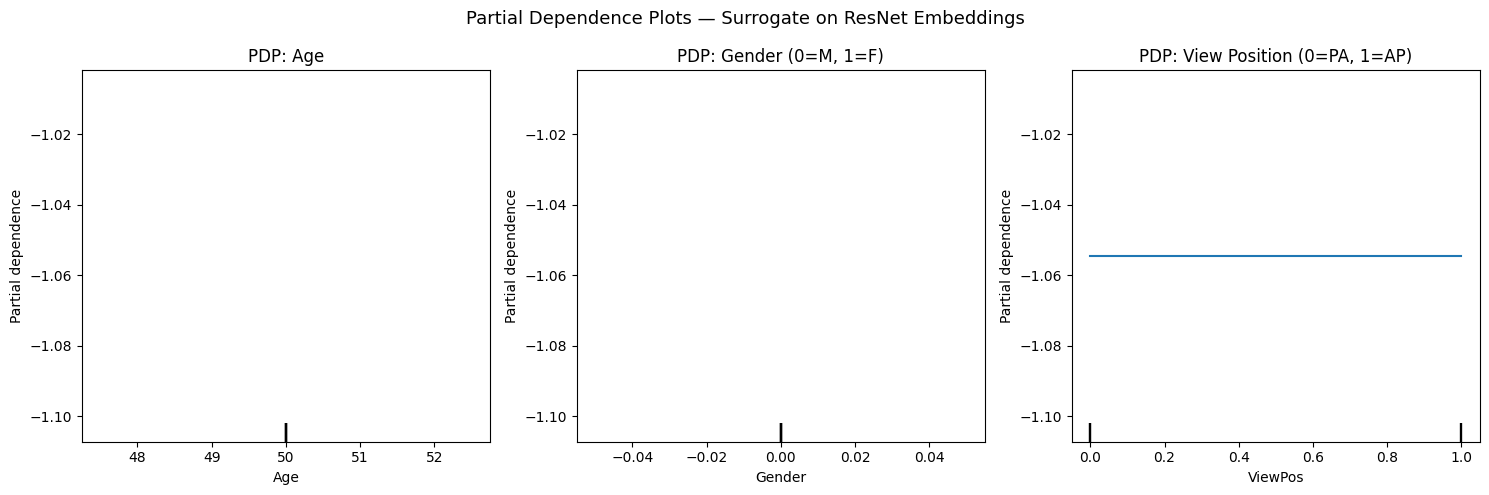

PDP metadata plot saved as pdp_resnet.png
Top embedding dimensions: [ 381  506 1893  590 2012]


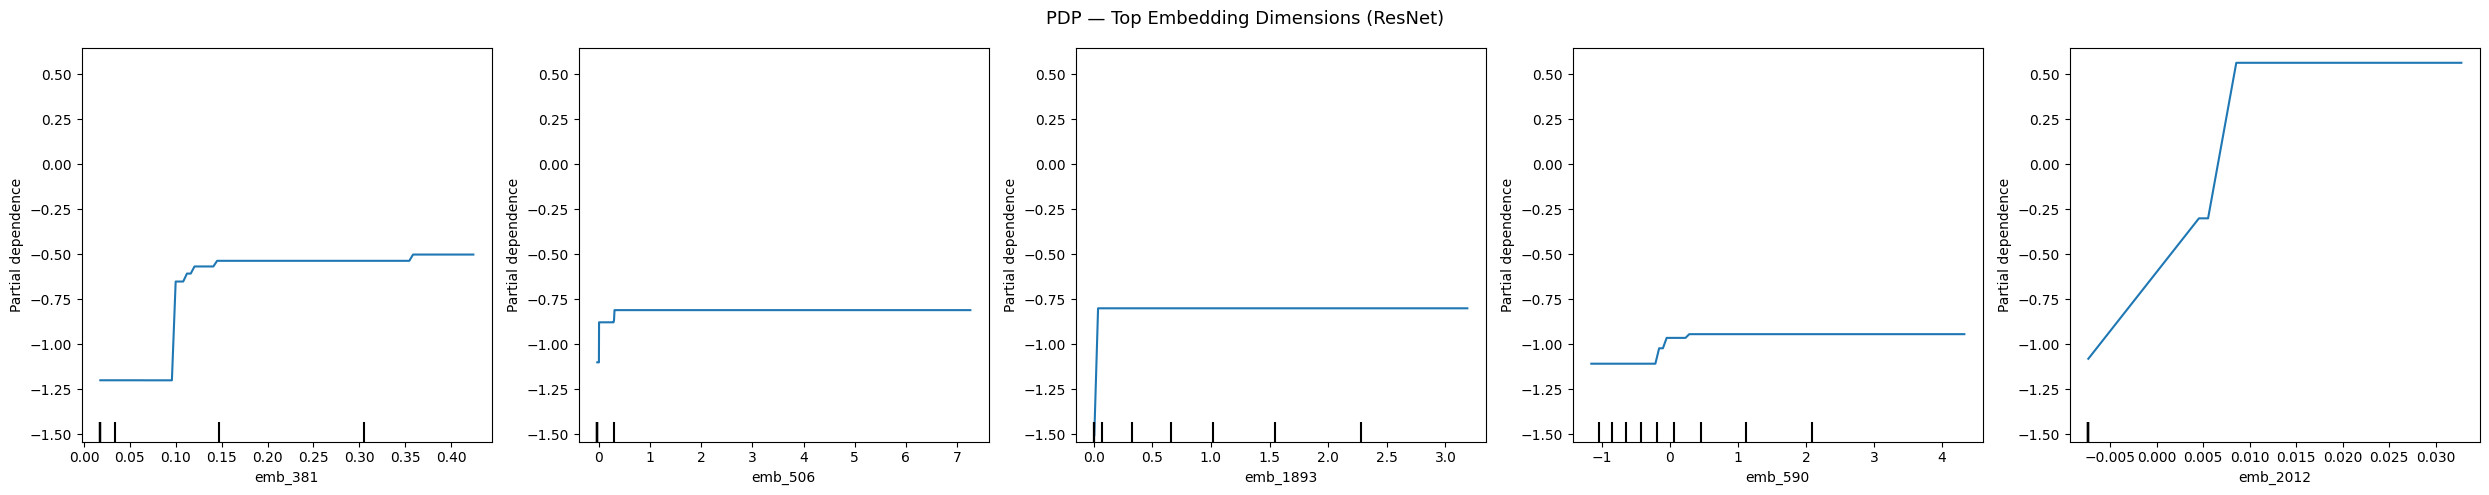

PDP embedding plot saved as pdp_embeddings_resnet.png


In [48]:
## 12. PDP — Partial Dependence Plots for ResNet Metadata Features

from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Create embedding model
# ============================================================

embedding_model = Model(
    inputs=resnet_model.input,
    outputs=resnet_model.layers[-3].output,
    name='resnet_embedding_model'
)

print('Embedding model output shape:', embedding_model.output_shape)


# ============================================================
# 2. Extract image embeddings
# ============================================================

def extract_embeddings(df_subset, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices(df_subset['path'].values)

    def _load(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=1)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.image.grayscale_to_rgb(img)
        img = tf.cast(img, tf.float32)

        # ResNet preprocessing
        img = preprocess_input(img)

        return img

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)

    emb = embedding_model.predict(ds, verbose=1)
    return emb


print('Extracting test embeddings...')
test_emb = extract_embeddings(test_df)
print('Test embeddings shape:', test_emb.shape)

print('Extracting train embeddings sample...')
train_sample = train_df_balanced.sample(
    min(500, len(train_df_balanced)),
    random_state=SEED
).reset_index(drop=True)

train_emb = extract_embeddings(train_sample)
print('Train embeddings shape:', train_emb.shape)


# ============================================================
# 3. Build safe metadata features
# ============================================================

def build_meta_features(df_subset):
    feats = pd.DataFrame(index=df_subset.index)

    # Age
    if 'Patient Age' in df_subset.columns:
        age = pd.to_numeric(df_subset['Patient Age'], errors='coerce')
        age = age.fillna(age.median())
        age = age.fillna(50)
        feats['Age'] = age
    else:
        feats['Age'] = 50.0

    # Gender
    if 'Patient Gender' in df_subset.columns:
        gender = df_subset['Patient Gender'].astype(str).str.upper().str.strip()
        feats['Gender'] = gender.map({
            'M': 0,
            'MALE': 0,
            'F': 1,
            'FEMALE': 1
        }).fillna(0)
    else:
        feats['Gender'] = 0

    # View Position
    if 'View Position' in df_subset.columns:
        view = df_subset['View Position'].astype(str).str.upper().str.strip()
        feats['ViewPos'] = view.map({
            'PA': 0,
            'AP': 1
        }).fillna(0)
    else:
        feats['ViewPos'] = 0

    return feats.astype(np.float32)


test_meta = build_meta_features(test_df.reset_index(drop=True)).values
train_meta = build_meta_features(train_sample).values


# ============================================================
# 4. Clean NaN / Inf values
# ============================================================

train_emb = np.nan_to_num(train_emb, nan=0.0, posinf=0.0, neginf=0.0)
test_emb = np.nan_to_num(test_emb, nan=0.0, posinf=0.0, neginf=0.0)

train_meta = np.nan_to_num(train_meta, nan=0.0, posinf=0.0, neginf=0.0)
test_meta = np.nan_to_num(test_meta, nan=0.0, posinf=0.0, neginf=0.0)


# ============================================================
# 5. Combine embeddings + metadata
# ============================================================

X_train_combined = np.concatenate([train_emb, train_meta], axis=1)
X_test_combined = np.concatenate([test_emb, test_meta], axis=1)

y_train_sub = train_sample['label'].values
y_test_sub = test_df['label'].values

print('Combined feature shape — train:', X_train_combined.shape)
print('Combined feature shape — test:', X_test_combined.shape)
print('NaNs in train:', np.isnan(X_train_combined).sum())
print('NaNs in test:', np.isnan(X_test_combined).sum())


# ============================================================
# 6. Train surrogate model
# ============================================================

surrogate = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=SEED
)

surrogate.fit(X_train_combined, y_train_sub)

print('Surrogate model accuracy:', surrogate.score(X_test_combined, y_test_sub))


# ============================================================
# 7. PDP for metadata features
# ============================================================

n_emb = train_emb.shape[1]

feat_names = [f'emb_{i}' for i in range(n_emb)] + [
    'Age',
    'Gender',
    'ViewPos'
]

meta_indices = [n_emb, n_emb + 1, n_emb + 2]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

PartialDependenceDisplay.from_estimator(
    surrogate,
    X_train_combined,
    features=meta_indices,
    feature_names=feat_names,
    kind='average',
    subsample=300,
    ax=ax,
    random_state=SEED
)

ax[0].set_title('PDP: Age')
ax[1].set_title('PDP: Gender (0=M, 1=F)')
ax[2].set_title('PDP: View Position (0=PA, 1=AP)')

plt.suptitle(
    'Partial Dependence Plots — Surrogate on ResNet Embeddings',
    fontsize=13
)

plt.tight_layout()
plt.savefig('pdp_resnet.png', dpi=120, bbox_inches='tight')
plt.show()

print('PDP metadata plot saved as pdp_resnet.png')


# ============================================================
# 8. PDP for top embedding dimensions
# ============================================================

importances = surrogate.feature_importances_
emb_importances = importances[:n_emb]

top_emb_idx = np.argsort(emb_importances)[-5:][::-1]

print('Top embedding dimensions:', top_emb_idx)

fig2, ax2 = plt.subplots(
    1,
    len(top_emb_idx),
    figsize=(5 * len(top_emb_idx), 5)
)

PartialDependenceDisplay.from_estimator(
    surrogate,
    X_train_combined,
    features=top_emb_idx.tolist(),
    feature_names=feat_names,
    kind='average',
    subsample=300,
    ax=ax2,
    random_state=SEED
)

plt.suptitle(
    'PDP — Top Embedding Dimensions (ResNet)',
    fontsize=13
)

plt.tight_layout()
plt.savefig('pdp_embeddings_resnet.png', dpi=120, bbox_inches='tight')
plt.show()

print('PDP embedding plot saved as pdp_embeddings_resnet.png')